In [241]:
import mesa
import seaborn as sns
import numpy as np
import pandas as pd
from collections import namedtuple
import matplotlib.ticker as mtick

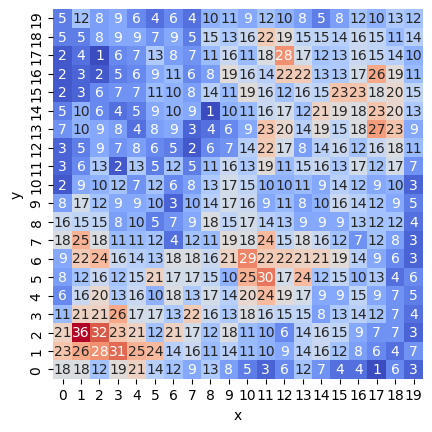

In [ ]:
LaunchPadConfig = namedtuple('LaunchPadConfig', ('x', 'y', 'num_uavs'))

def compute_coverage(model):
    """Fraction of cells visited at least once"""
    return np.count_nonzero(model.coverage > 0) / model.coverage.size

def compute_redundancy(model):
    visited_cells = model.coverage_matrix[model.coverage_matrix > 0]
    if len(visited_cells) <= 0:
        return 0
    return visited_cells.mean()

class UAVModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, width, height, launch_pads):
        super().__init__()
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Coverage": compute_coverage,
                "Redundance": compute_redundancy}
        )
        
        self.grid = mesa.space.MultiGrid(width, height, torus=False) # creates space
        self.coverage = np.zeros((height, width), dtype=int) # coverage matrix to track visits per cell
        self.launch_pads = self.create_launchpads(launch_pads=launch_pads)
        for pad in self.launch_pads:
            pad.spawn_uavs(model=self)
        

    def create_launchpads(self, launch_pads):
        """Creates launchpad on the grid"""
        pads = []
        for p in launch_pads:
            pads.append(LaunchPad((p.x, p.y), p.num_uavs))
        return pads


    def step(self):
        self.agents.do("move")
        self.agents.do("inspect")
        self.datacollector.collect(self)


class LaunchPad():
    """A location for start and landing of UAVs"""

    def __init__(self, pos, num_uavs):
        self.pos = pos
        self.num_uavs = num_uavs
        

    def spawn_uavs(self, model):
        """Spawns n UAVs on the launch pad"""
        self.uavs = UAVAgent.create_agents(model=model, n=self.num_uavs)
        for a in self.uavs:
            model.grid.place_agent(a, self.pos)
            a.track_position()
            a.inspect()



class UAVAgent(mesa.Agent):
    """A model with UAV agents exploring a 2D grid and recording coverage"""

    def __init__(self, model):
        super().__init__(model) 
        self.track = []

    def track_position(self):
        """Keeps track of the trajectory of a UAV"""
        self.track.append(self.pos)

    def move(self):
        """Moves the drone to another cell"""
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)
        self.track_position()

    def inspect(self):
        """Drone inspects the cell"""
        y, x = self.pos
        self.model.coverage[y][x] += 1


LAUNCH_PADS = [LaunchPadConfig(0,0,10)]
GRID_SIZE = 20
ITERATIONS = 500

model = UAVModel(GRID_SIZE,GRID_SIZE,LAUNCH_PADS)  # Tells the model to create 10 agents
for _ in range(ITERATIONS):  # Runs the model for 10 steps; an underscore is common convention for a variable that is not used
    model.step()

data = model.coverage

ax = sns.heatmap(data, cmap="coolwarm", annot=True, cbar=False, square=True)
ax.invert_yaxis()  # put y=0 at the bottom
ax.set_xlabel("x")
ax.set_ylabel("y");

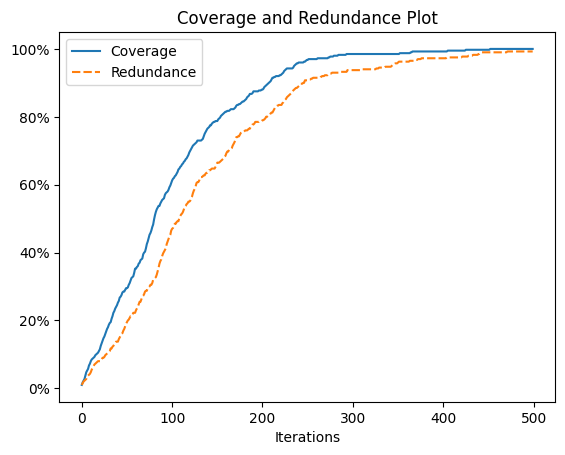

In [246]:
data_df = model.datacollector.get_model_vars_dataframe()
g = sns.lineplot(data=data_df)
g.set(title="Coverage and Redundance Plot", xlabel="Iterations")
g.yaxis.set_major_formatter(mtick.PercentFormatter(1.0));

Text(0.5, 1.0, 'Distribution of Cell Inspections')

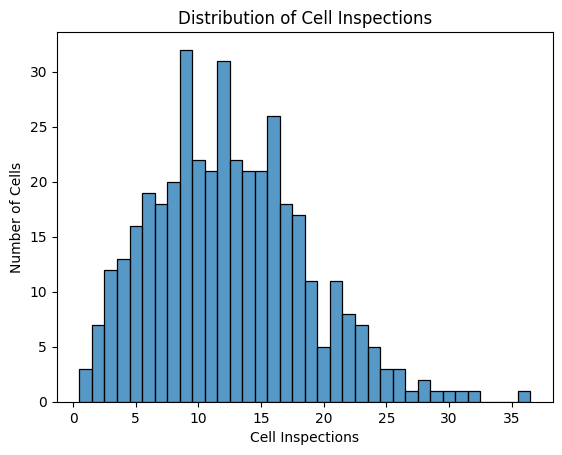

In [247]:
# Flatten coverage matrix into 1D array
values = model.coverage.flatten()

# Histogram with seaborn
ax = sns.histplot(values, bins=range(values.max() + 2), discrete=True)

ax.set_xlabel("Cell Inspections")
ax.set_ylabel("Number of Cells")
ax.set_title("Distribution of Cell Inspections")
